In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath("../src"))
from feature_engineering import run_feature_engineering_pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

INPUT_PATH   = "../data/processed/churn_fintech_renamed.csv"
OUTPUT_PATH  = "../data/processed/churn_features.csv"
FIGURES_PATH = "../reports/figures"

print("Imports successful")

Imports successful


In [11]:
df_raw = pd.read_csv(INPUT_PATH)
print(f"Input shape: {df_raw.shape}")

df = run_feature_engineering_pipeline(df_raw)
print(f"Output shape: {df.shape}")
print(f"\nNew columns added: {df.shape[1] - df_raw.shape[1]}")
print(f"\nNew feature names:")
new_cols = set(df.columns) - set(df_raw.columns)
for col in sorted(new_cols):
    print(f"  + {col}")

Input shape: (7043, 21)
Output shape: (7043, 29)

New columns added: 8

New feature names:
  + charge_consistency
  + is_autopay
  + is_early_stage
  + is_high_value
  + is_multi_product
  + product_adoption_score
  + revenue_per_month
  + tenure_group


In [12]:
# charge_consistency → measures how consistent the customer's charges are over time
#                      (relationship between monthly_charges, total_charges, and tenure)

# is_autopay → indicates whether the customer uses automatic payment
#              1 = automatic payment, 0 = manual payment

# is_early_stage → indicates whether the customer is in the early lifecycle stage
#                  typically months_as_customer <= 12

# is_high_value → indicates whether the customer generates high monthly revenue

# is_multi_product → indicates whether the customer uses multiple products/services

# product_adoption_score → total number of products/services the customer uses

# revenue_per_month → average monthly revenue generated by the customer

# tenure_group → customer tenure category
#                e.g., early (0–12), growing (12–24), established (24–48), loyal (48+)

In [13]:
print("=== DATA QUALITY CHECKS ===")
print(f"Rows before: {df_raw.shape[0]}")
print(f"Rows after:  {df.shape[0]}")
print(f"\nNull values in engineered features:")
new_feature_cols = [
    "revenue_per_month", "charge_consistency", "is_high_value",
    "is_early_stage", "tenure_group", "product_adoption_score",
    "is_multi_product", "is_autopay"
]
print(df[new_feature_cols].isnull().sum())
print(f"\nTarget distribution after encoding:")
print(df["churned"].value_counts())
print(f"Churn rate: {df['churned'].mean()*100:.2f}%")

=== DATA QUALITY CHECKS ===
Rows before: 7043
Rows after:  7043

Null values in engineered features:
revenue_per_month          0
charge_consistency         0
is_high_value              0
is_early_stage             0
tenure_group              11
product_adoption_score     0
is_multi_product           0
is_autopay                 0
dtype: int64

Target distribution after encoding:
churned
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54%


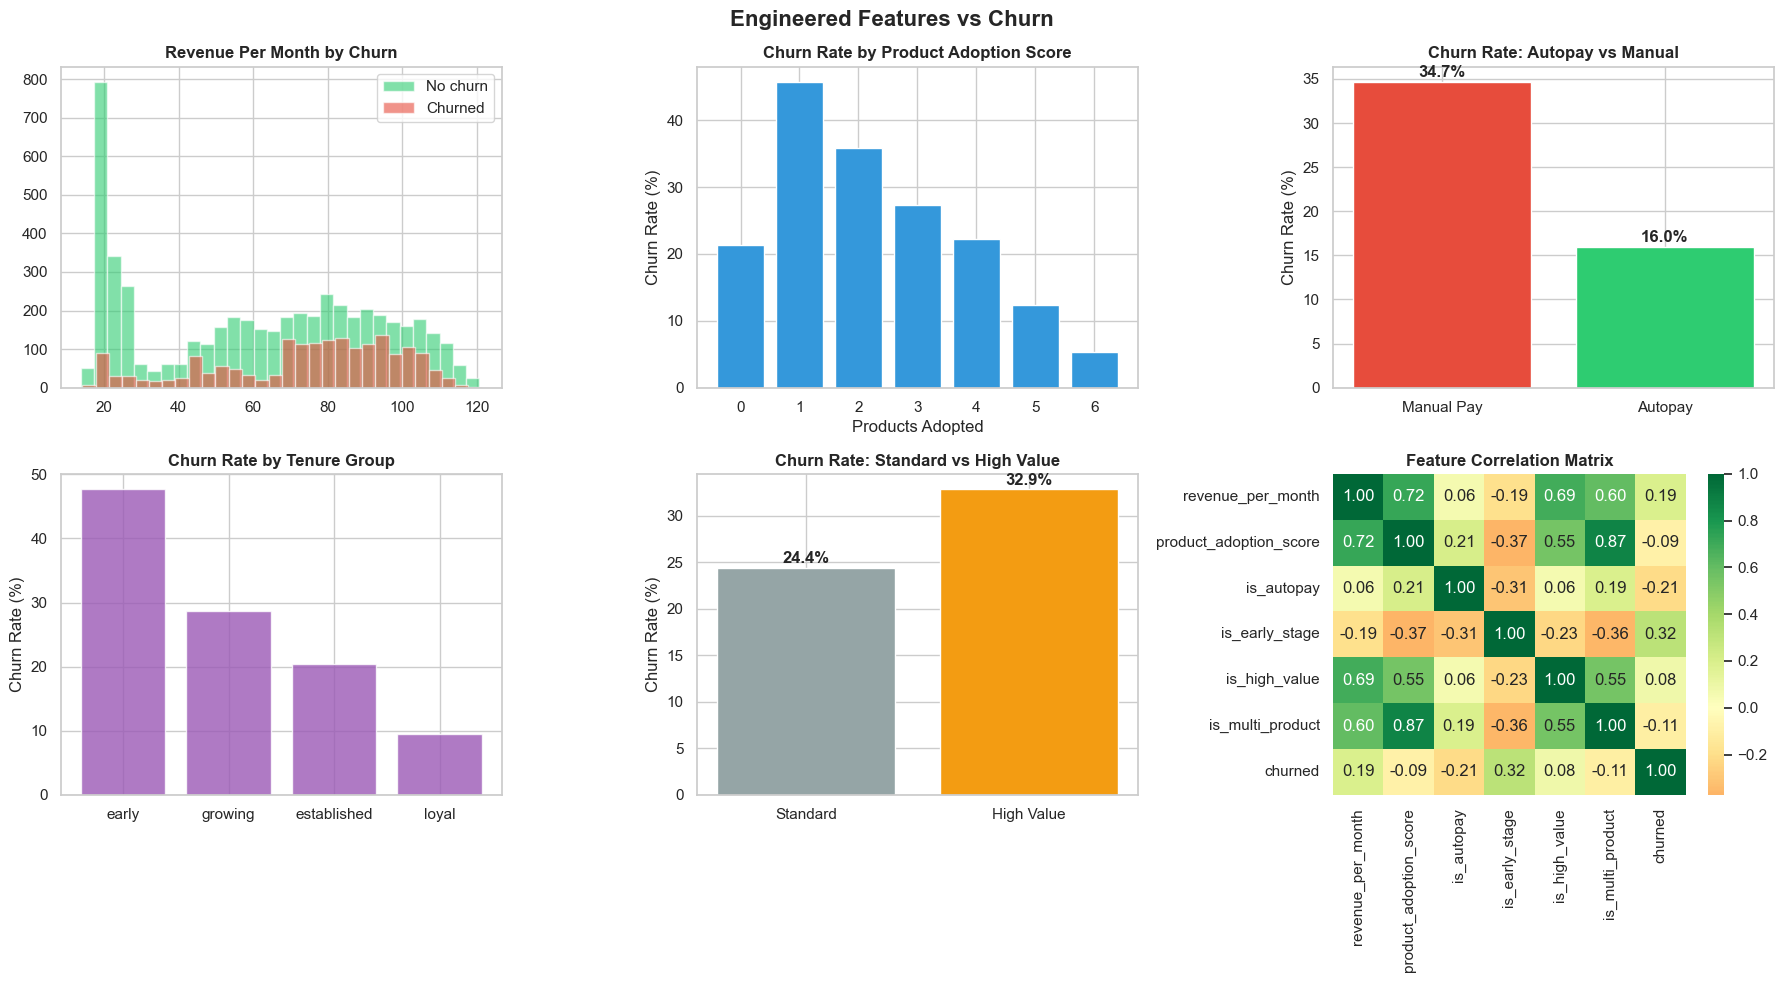

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Revenue per month by churn
axes[0,0].hist(df[df["churned"]==0]["revenue_per_month"], bins=30,
               alpha=0.6, color="#2ecc71", label="No churn")
axes[0,0].hist(df[df["churned"]==1]["revenue_per_month"], bins=30,
               alpha=0.6, color="#e74c3c", label="Churned")
axes[0,0].set_title("Revenue Per Month by Churn", fontweight="bold")
axes[0,0].legend()

# Product adoption score by churn
churn_by_adoption = df.groupby("product_adoption_score")["churned"].mean() * 100
axes[0,1].bar(churn_by_adoption.index, churn_by_adoption.values, color="#3498db")
axes[0,1].set_title("Churn Rate by Product Adoption Score", fontweight="bold")
axes[0,1].set_ylabel("Churn Rate (%)")
axes[0,1].set_xlabel("Products Adopted")

# Autopay vs churn
autopay_churn = df.groupby("is_autopay")["churned"].mean() * 100
axes[0,2].bar(["Manual Pay", "Autopay"], autopay_churn.values,
              color=["#e74c3c", "#2ecc71"])
axes[0,2].set_title("Churn Rate: Autopay vs Manual", fontweight="bold")
axes[0,2].set_ylabel("Churn Rate (%)")
for i, v in enumerate(autopay_churn.values):
    axes[0,2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Tenure group by churn
tenure_churn = df.groupby("tenure_group")["churned"].mean() * 100
tenure_order = ["early", "growing", "established", "loyal"]
tenure_churn = tenure_churn.reindex(tenure_order)
axes[1,0].bar(tenure_churn.index, tenure_churn.values, color="#9b59b6", alpha=0.8)
axes[1,0].set_title("Churn Rate by Tenure Group", fontweight="bold")
axes[1,0].set_ylabel("Churn Rate (%)")

# High value vs churn
hv_churn = df.groupby("is_high_value")["churned"].mean() * 100
axes[1,1].bar(["Standard", "High Value"], hv_churn.values,
              color=["#95a5a6", "#f39c12"])
axes[1,1].set_title("Churn Rate: Standard vs High Value", fontweight="bold")
axes[1,1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(hv_churn.values):
    axes[1,1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Correlation heatmap of new features
corr_cols = ["revenue_per_month", "product_adoption_score",
             "is_autopay", "is_early_stage", "is_high_value",
             "is_multi_product", "churned"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[1,2])
axes[1,2].set_title("Feature Correlation Matrix", fontweight="bold")

plt.suptitle("Engineered Features vs Churn", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/07_engineered_features.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Feature dataset saved to {OUTPUT_PATH}")
print(f"Final shape: {df.shape}")
print(f"\nFinal columns ({df.shape[1]} total):")
for col in df.columns:
    print(f"  {col}")